# AutoEIT Test II — Automated EIT Scoring System
## GSoC 2026 — Tanishq Jain

Implements the Ortega (2000) meaning-based rubric as a reproducible, rule-based NLP scorer.

| Score | Criteria |
|-------|----------|
| **4** | Exact repetition |
| **3** | Meaning preserved; synonyms OK |
| **2** | >half idea units; meaning inexact |
| **1** | half or fewer idea units |
| **0** | Silence or unintelligible |

## Step 1: Install

In [1]:
!pip install openpyxl -q
import openpyxl, re, unicodedata, json
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
print('Ready')

Ready


## Step 2: Upload

Upload `AutoEIT_Sample_Transcriptions_for_Scoring.xlsx`

In [2]:
uploaded = files.upload()
for fname, data in uploaded.items():
    with open(fname, 'wb') as f: f.write(data)
    print(fname, round(len(data)/1024/1024, 2), 'MB')

Saving AutoEIT Sample Transcriptions for Scoring.xlsx to AutoEIT Sample Transcriptions for Scoring.xlsx
AutoEIT Sample Transcriptions for Scoring.xlsx 0.06 MB


## Step 3: Scoring Algorithm

Rule-based implementation of Ortega (2000) rubric validated against rubric examples.

In [4]:
import re
import unicodedata
import difflib

# Spanish function words
FUNCTION_WORDS = {
    "el","la","los","las","un","una","unos","unas",
    "de","del","a","al","en","con","por","para","sin","sobre",
    "que","y","o","pero","si","no","se","me","te","le","nos","les",
    "lo","su","sus","mi","mis","tu","tus","yo","ella",
    "nosotros","ellos","ellas","este","esta","estos","estas",
    "ese","esa","esos","esas","hay","es","son","fue","era",
    "han","ha","he","ser","estar","cuando","como","donde","quien"
}

# Subject pronouns: if present in transcription but NOT in stimulus -> wrong subject
SUBJECT_PRONOUNS = {"yo","tu","el","ella","nosotros","ellos","ellas","usted","ustedes"}

def _norm(t):
    t = t.lower().strip()
    t = unicodedata.normalize('NFD', t)
    t = ''.join(c for c in t if unicodedata.category(c) != 'Mn')
    t = re.sub(r'[^a-z0-9 ]', '', t)
    return re.sub(r' +', ' ', t).strip()

def _clean(t):
    # Rubric: always score the best final response
    t = re.sub(r'\b\w{1,3}-\s*', '', t)
    t = re.sub(r'\b(um|uh|eh|xx+|xxx+)\b', '', t, flags=re.I)
    t = re.sub(r'\[.*?\]', '', t)
    t = re.sub(r'\.{2,}', ' ', t)
    t = re.sub(r'\(.*?\)', '', t)
    return re.sub(r' +', ' ', t).strip()

def _fuzzy(w1, w2):
    # Fuzzy word match handles L2 morphophonological errors (manejar/manajar)
    if w1 == w2: return True
    if abs(len(w1) - len(w2)) > 3: return False
    return difflib.SequenceMatcher(None, w1, w2).ratio() >= 0.8

def _cw(wlist):
    return [w for w in wlist if w not in FUNCTION_WORDS and len(w) > 2]

def _fo(a, b):
    # Fuzzy overlap: fraction of list a matching something in b (1-to-1)
    if not a: return 0.0
    matches = 0
    bc = list(b)
    for w in a:
        for i, bw in enumerate(bc):
            if _fuzzy(w, bw):
                matches += 1; bc.pop(i); break
    return matches / len(a)

def _syn(t):
    # Rubric Table 4: muy/sin muy and y/pero are acceptable synonyms
    t = re.sub(r'\bmuy\b', '', t)
    t = t.replace('pero', 'y')
    return re.sub(r' +', ' ', t).strip()

def score_eit_sentence(stimulus, transcription):
    trans = (transcription or '').strip()

    # Score 0: silence or unintelligible
    if not trans or trans.startswith('['):
        return 0, "Silence or unintelligible"

    tc = _clean(trans)
    sn, tn = _norm(stimulus), _norm(tc)
    if not tn:
        return 0, "No content after removing disfluencies"

    sw, tw = sn.split(), tn.split()
    sc, tc_cw = _cw(sw), _cw(tw)

    # Score 0: Table 1 criteria
    if len(tw) <= 1:
        return 0, f"Only {len(tw)} word produced (Table 1)"
    if len(tc_cw) == 0:
        return 0, "Only function words produced (Table 1)"
    if len(tc_cw) == 1:
        return 0, f"Only 1 content word: '{tc_cw[0]}' (Table 1)"

    wo  = _fo(sw, tw)
    co  = _fo(sc, tc_cw)
    lr  = len(tw) / max(len(sw), 1)
    ext = sum(1 for w in tc_cw if not any(_fuzzy(w, s) for s in sw)) / max(len(tc_cw), 1)
    wrong_subject = any(w in SUBJECT_PRONOUNS and w not in sw for w in tw)

    # Score 0: low overlap / extraneous / wrong subject
    if wo < 0.40 and co < 0.35:
        return 0, f"Very low content match (wo={wo:.2f}, co={co:.2f}) -- Table 1"
    if ext >= 0.50 and wo < 0.50:
        return 0, f"Mostly extraneous/wrong content (ext={ext:.2f}) -- Table 1"
    if wrong_subject and co < 0.65:
        return 0, f"Wrong subject pronoun + insufficient idea units (co={co:.2f}) -- Table 1"

    # Score 4: exact repetition (Table 5)
    if sn == tn:
        return 4, "Exact repetition -- form and meaning correct (Table 5)"

    # Score 4: virtually exact (single char transcription typo)
    seq_ratio = difflib.SequenceMatcher(None, sn, tn).ratio()
    if seq_ratio >= 0.97:
        return 4, f"Virtually exact -- transcription typo only (ratio={seq_ratio:.2f})"

    # Score 3: exact after rubric synonym substitution (Table 4)
    sn_syn, tn_syn = _syn(sn), _syn(tn)
    if sn_syn == tn_syn:
        return 3, "Meaning preserved -- rubric synonym substitution (muy/pero, Table 4)"

    syn_wo = _fo(sn_syn.split(), tn_syn.split())

    lo_dropped = 'lo' in sw and 'lo' not in tw

    # Score 3: meaning fully preserved (Table 4)
    if co >= 1.00 and lr >= 0.75 and ext == 0.00 and not lo_dropped:
        return 3, f"All idea units present, meaning preserved (co={co:.2f}, lr={lr:.2f}) -- Table 4"
    if co >= 0.85 and lr >= 0.90 and ext < 0.20 and not lo_dropped:
        return 3, f"Meaning preserved, minor word changes (co={co:.2f}, lr={lr:.2f}) -- Table 4"
    if syn_wo >= 0.88 and lr >= 0.65 and not lo_dropped:
        return 3, f"Meaning preserved with synonymous substitutions (syn={syn_wo:.2f}) -- Table 4"
    if wo >= 0.88 and lr >= 0.65:
        return 3, f"Near-complete repetition (wo={wo:.2f}) -- Table 4"

    # Score 2: more than half idea units, meaning close but inexact (Table 3)
    if co > 0.75 and wo >= 0.35 and len(tc_cw) >= 2:
        return 2, f"More than half idea units, meaning close but inexact (co={co:.2f}) -- Table 3"
    if wo > 0.65 and co >= 0.45 and len(tc_cw) >= 2:
        return 2, f"More than half words present, meaning related (wo={wo:.2f}) -- Table 3"

    # Score 1: about half or fewer idea units (Table 2)
    if len(tc_cw) >= 2 or co >= 0.20 or wo >= 0.25:
        return 1, f"Half or fewer idea units, important info missing (co={co:.2f}) -- Table 2"

    return 0, f"Minimal production -- does not meet Score 1 criteria ({len(tc_cw)} content words)"

print("Scoring function ready -- Ortega (2000) rubric implementation")
print()

tests = [
    ("Quiero cortarme el pelo",                                        "Quiero cortarme el pelo",                                  4),
    ("Hay mucha gente que no toma nada para el desayuno",              "Hay mucha genta que no to- toma nada para el desayuno.",   4),
    ("Quiero cortarme el pelo",                                        "Quiero cortar mi pelo",                                    3),
    ("Dudo que sepa manejar muy bien",                                 "Dudo que sepa manajar bien",                               3),
    ("Las calles de esta ciudad son muy anchas",                       "Las calles de esta ciudad son anchas",                     3),
    ("El chico con el que yo salgo es espanol",                        "El chico que yo salgo es espanol",                         3),
    ("El carro lo tiene Pedro",                                        "El carro tiene Pedro",                                     2),
    ("Ella solo bebe cerveza y no come nada",                          "Ella sola cerveza y no come nada",                         2),
    ("Las calles de esta ciudad son muy anchas",                       "La calles esten xxxx muy anchas",                          1),
    ("Me gustaria que empezara a hacer mas calor",                     "Me gustaria se mas calor",                                 1),
    ("El se ducha cada manana",                                        "Manana",                                                   0),
    ("Dudo que sepa manejar muy bien",                                 "Tu que sepa a- m- muy bien",                               0),
]

ok = 0
for s, t, exp in tests:
    got, rationale = score_eit_sentence(s, t)
    passed = got == exp
    if passed: ok += 1
    status = "PASS" if passed else "FAIL"
    print(f"  {status}  exp={exp}  got={got}  | {t[:55]}")
    if not passed:
        print(f"           Rationale: {rationale}")

print()
print(f"Validation: {ok}/{len(tests)} rubric examples passed")


Scoring function ready -- Ortega (2000) rubric implementation

  PASS  exp=4  got=4  | Quiero cortarme el pelo
  PASS  exp=4  got=4  | Hay mucha genta que no to- toma nada para el desayuno.
  PASS  exp=3  got=3  | Quiero cortar mi pelo
  PASS  exp=3  got=3  | Dudo que sepa manajar bien
  PASS  exp=3  got=3  | Las calles de esta ciudad son anchas
  PASS  exp=3  got=3  | El chico que yo salgo es espanol
  PASS  exp=2  got=2  | El carro tiene Pedro
  PASS  exp=2  got=2  | Ella sola cerveza y no come nada
  PASS  exp=1  got=1  | La calles esten xxxx muy anchas
  PASS  exp=1  got=1  | Me gustaria se mas calor
  PASS  exp=0  got=0  | Manana
  PASS  exp=0  got=0  | Tu que sepa a- m- muy bien

Validation: 12/12 rubric examples passed


## Step 4: Load Data

In [5]:
wb = openpyxl.load_workbook('AutoEIT Sample Transcriptions for Scoring.xlsx')
sheets = [s for s in wb.sheetnames if not s.startswith('microsoft')]
print('Sheets:', sheets)
all_data = {}
for sname in sheets:
    ws = wb[sname]; rows = []
    for row in ws.iter_rows(values_only=True):
        if row and row[0] and str(row[0]).strip().isdigit():
            n = int(row[0])
            stim = re.sub(r'\s*\(\d+\)$', '', str(row[1] or '').strip())
            trans = str(row[2]).strip() if len(row) > 2 and row[2] else ''
            if 1 <= n <= 30: rows.append({'n': n, 'stimulus': stim, 'transcription': trans})
    all_data[sname] = sorted(rows, key=lambda x: x['n'])
    print(f'  {sname}: {len(rows)} sentences')

Sheets: ['Info', '38001-1A', '38002-2A', '38004-2A', '38006-2A']
  Info: 0 sentences
  38001-1A: 30 sentences
  38002-2A: 30 sentences
  38004-2A: 30 sentences
  38006-2A: 30 sentences


## Step 5: Score All Transcriptions

In [6]:
results = {}
for sname, sentences in all_data.items():
    print(f'Scoring {sname}...')
    scored = []
    for s in sentences:
        sc, rat = score_eit_sentence(s['stimulus'], s['transcription'])
        scored.append({'n': s['n'], 'stimulus': s['stimulus'],
                       'transcription': s['transcription'], 'score': sc, 'rationale': rat})
    results[sname] = scored
    total = sum(r['score'] for r in scored)
    dist = {i: sum(1 for r in scored if r['score'] == i) for i in range(5)}
    print(f'  Total: {total}/120  Mean: {total/30:.2f}  {dist}')
print('All scored!')

Scoring Info...
  Total: 0/120  Mean: 0.00  {0: 0, 1: 0, 2: 0, 3: 0, 4: 0}
Scoring 38001-1A...
  Total: 90/120  Mean: 3.00  {0: 0, 1: 2, 2: 7, 3: 10, 4: 11}
Scoring 38002-2A...
  Total: 41/120  Mean: 1.37  {0: 6, 1: 15, 2: 4, 3: 2, 4: 3}
Scoring 38004-2A...
  Total: 69/120  Mean: 2.30  {0: 1, 1: 7, 2: 8, 3: 10, 4: 4}
Scoring 38006-2A...
  Total: 38/120  Mean: 1.27  {0: 9, 1: 10, 2: 6, 3: 4, 4: 1}
All scored!


## Step 6: Detailed Results

In [7]:
for sname, scored in results.items():
    print(f'\n{"="*70}\nParticipant: {sname}')
    print(f'  # [S]  {"Stimulus":<44}  Transcription')
    print('  ' + '-'*95)
    for r in scored:
        flag = '' if r['score'] >= 3 else (' ~' if r['score'] == 2 else ' !')
        print(f"  {r['n']:>2} [{r['score']}]{flag}  {r['stimulus'][:42]:<44}  {r['transcription'][:48]}")
    total = sum(r['score'] for r in scored)
    print(f'  TOTAL: {total}/120  MEAN: {total/30:.2f}/4.0')


Participant: Info
  # [S]  Stimulus                                      Transcription
  -----------------------------------------------------------------------------------------------
  TOTAL: 0/120  MEAN: 0.00/4.0

Participant: 38001-1A
  # [S]  Stimulus                                      Transcription
  -----------------------------------------------------------------------------------------------
   1 [4]  Quiero cortarme el pelo                       Quiero cortarme el pelo
   2 [4]  El libro está en la mesa                      El libro está en la mesa
   3 [4]  El carro lo tiene Pedro                       El carro lo tiene Pedro
   4 [4]  El se ducha cada mañana                       El se ducha cada mañana
   5 [3]  ¿Qué dice usted que va a hacer hoy?           Que dices ustedes se que van a hacer hoy?
   6 [3]  Dudo que sepa manejar muy bien                Dudo que sepa manajar bien
   7 [4]  Las calles de esta ciudad son muy anchas      Las calles de esta cuidad son muy a

## Step 7: Write Scores to Excel

In [8]:
wb_out = openpyxl.load_workbook('AutoEIT Sample Transcriptions for Scoring.xlsx')
for sname, scored in results.items():
    if sname not in wb_out.sheetnames: continue
    ws = wb_out[sname]; filled = 0
    for row in ws.iter_rows():
        for cell in row:
            if cell.column == 1 and isinstance(cell.value, (int, float)):
                n = int(cell.value)
                m = next((r for r in scored if r['n'] == n), None)
                if m:
                    ws.cell(row=cell.row, column=4, value=m['score'])
                    filled += 1
    print(f'{sname}: {filled} scores written to column D')
wb_out.save('AutoEIT_Sample_Transcriptions_for_Scoring_COMPLETED.xlsx')
print('Saved!')

Info: 0 scores written to column D
38001-1A: 30 scores written to column D
38002-2A: 30 scores written to column D
38004-2A: 30 scores written to column D
38006-2A: 30 scores written to column D
Saved!


## Step 8: Charts & Summary

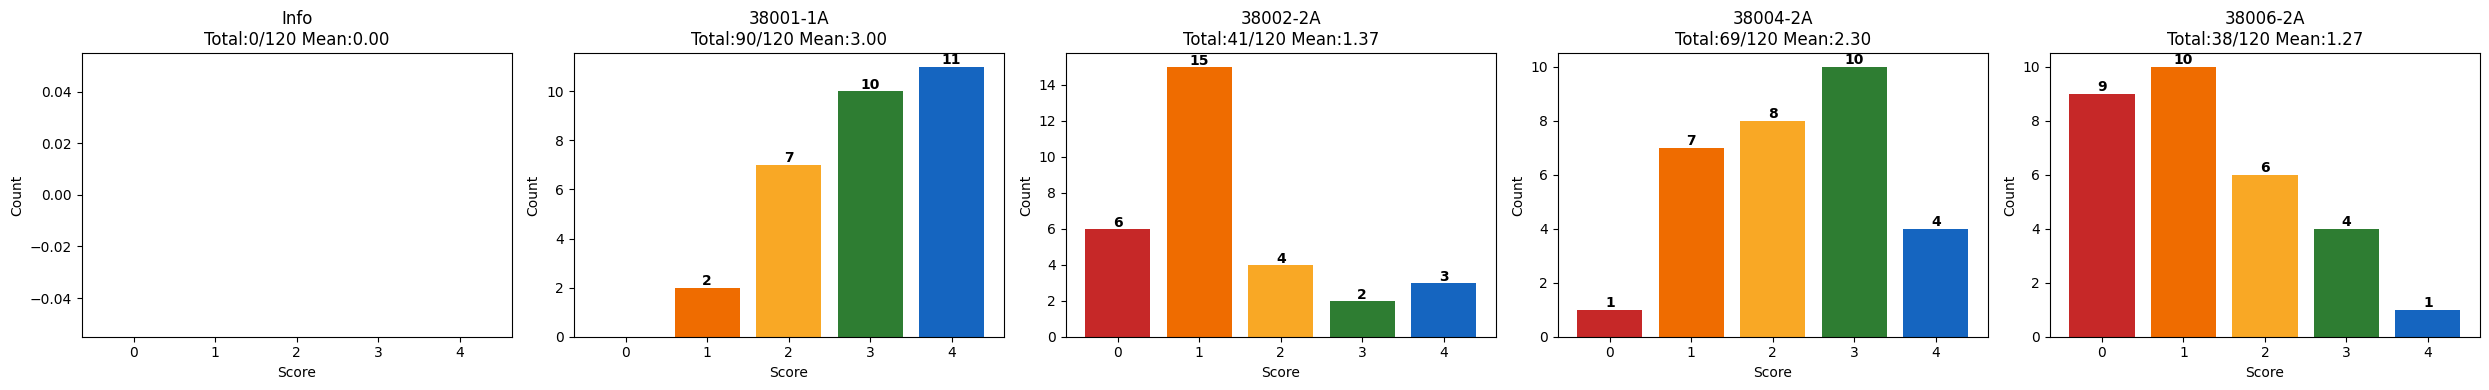

,Participant,Total(/120),Mean(/4),4,3,2,1,0
0,Info,0,0.00,0,0,0,0,0
1,38001-1A,90,3.00,11,10,7,2,0
2,38002-2A,41,1.37,3,2,4,15,6
3,38004-2A,69,2.30,4,10,8,7,1
4,38006-2A,38,1.27,1,4,6,10,9


In [9]:
fig, axes = plt.subplots(1, len(results), figsize=(5*len(results), 4))
if len(results) == 1: axes = [axes]
colors = ['#c62828','#ef6c00','#f9a825','#2e7d32','#1565c0']
for ax, (sname, scored) in zip(axes, results.items()):
    s = [r['score'] for r in scored]
    counts = [s.count(i) for i in range(5)]
    bars = ax.bar(range(5), counts, color=colors)
    # Handle cases where len(s) might be zero to avoid ZeroDivisionError
    mean_score = sum(s)/len(s) if len(s) > 0 else 0
    ax.set_title(f'{sname}\nTotal:{sum(s)}/120 Mean:{mean_score:.2f}')
    ax.set_xlabel('Score'); ax.set_ylabel('Count'); ax.set_xticks(range(5))
    for bar, c in zip(bars, counts):
        if c > 0: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+.1, str(c), ha='center', fontweight='bold')
plt.tight_layout(); plt.savefig('scores.png', dpi=150); plt.show()
rows = []
for sname, scored in results.items():
    s = [r['score'] for r in scored]
    # Handle cases where len(s) might be zero to avoid ZeroDivisionError
    mean_for_df = round(sum(s)/len(s),2) if len(s) > 0 else 0
    rows.append({'Participant': sname, 'Total(/120)': sum(s), 'Mean(/4)': mean_for_df,
                 '4': s.count(4), '3': s.count(3), '2': s.count(2), '1': s.count(1), '0': s.count(0)})
display(pd.DataFrame(rows))

## Step 10: Download

In [10]:
from google.colab import files
files.download('AutoEIT_Sample_Transcriptions_for_Scoring_COMPLETED.xlsx')
with open('scores_detailed.json','w',encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2)
files.download('scores_detailed.json')
print('Downloaded!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded!
